# Lab 3

## Task 1

The servo is making weird periodic noises, it speerd up every couple of cycles without an apparent pattern.. 

Also the Ai0 is broken, Gonna use Ai1 instad.

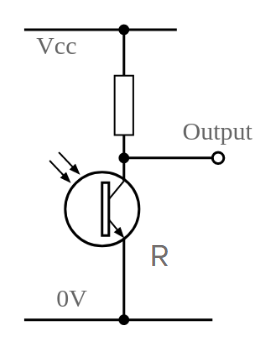
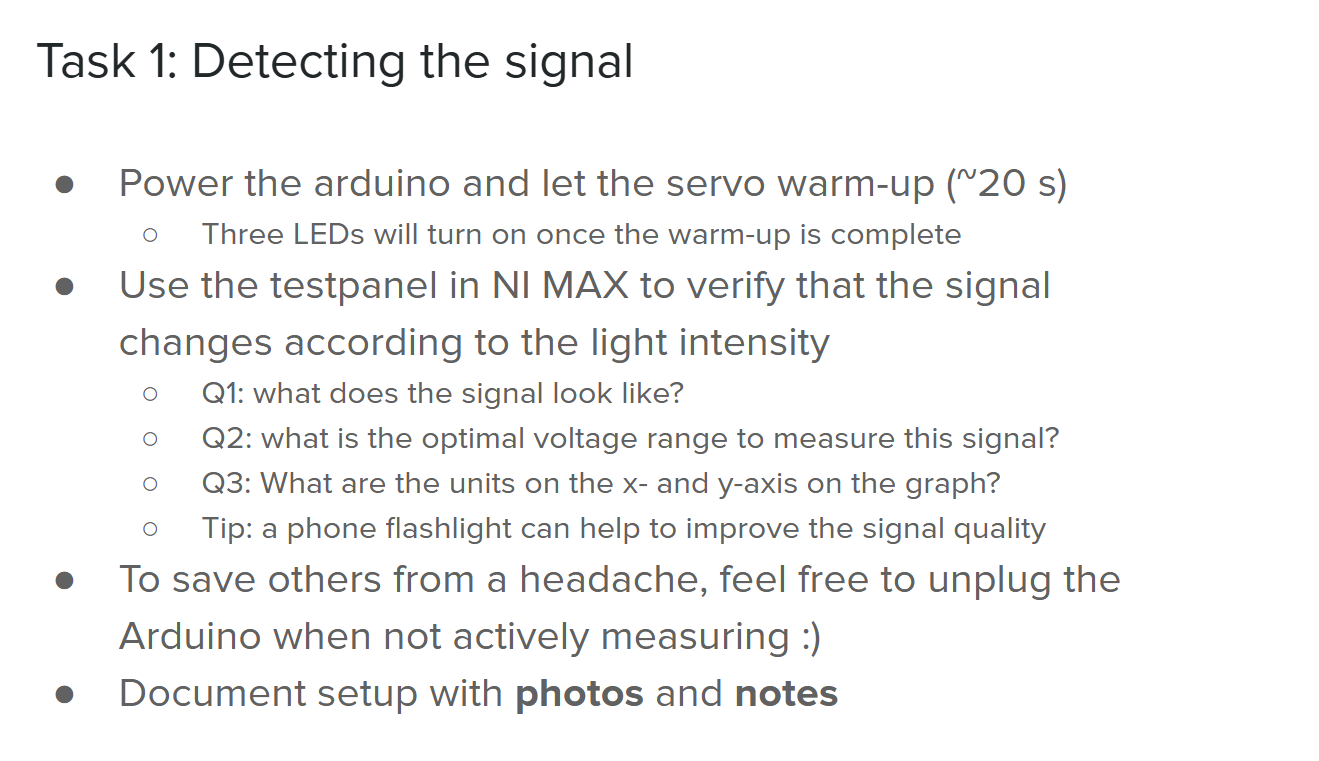


In [77]:
import nidaqmx
import time

import numpy as np
import numpy.typing
from typing import Tuple

import pandas as pd
import pickle 

import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, ProductCategory
from nidaqmx.constants import TerminalConfiguration
from nidaqmx.constants import AcquisitionType, READ_ALL_AVAILABLE

Acquired data: [3.538943, 3.537463, 3.539108, 3.540095, 3.541410, 3.543713, 3.544371, 3.543713, 3.544535, 3.547002, 3.548976, 3.555719, 3.564436, 3.574468, 3.584830, 3.595027, 3.605224, 3.616243, 3.626604, 3.638446, 3.649465, 3.662129, 3.675615, 3.690582, 3.704068, 3.719035, 3.734494, 3.747652, 3.763770, 3.783835, 3.810972, 3.842056, 3.874456, 3.908830, 3.945670, 3.983991, 4.022806, 4.063923, 4.105698, 4.150926, 4.200267, 4.252403, 4.308322, 4.370820, 4.440720, 4.514895, 4.576571, 4.616537, 4.642359, 4.661273, 4.677391, 4.693016, 4.703048, 4.709298, 4.713081, 4.713410, 4.713410, 4.713081, 4.712259, 4.712423, 4.710614, 4.710120, 4.708969, 4.707818, 4.708640, 4.709463, 4.708805, 4.708969, 4.707982, 4.706502, 4.707324, 4.705022, 4.706173, 4.705680, 4.705515, 4.704364, 4.705680, 4.704200, 4.703706, 4.702884, 4.701897, 4.700910, 4.701897, 4.700581, 4.700910, 4.700746, 4.700417, 4.700417, 4.700746, 4.699759, 4.699594, 4.699101, 4.698937, 4.698443, 4.699430, 4.698279, 4.697785, 4.697621, 4.69

Text(0.5, 0, 'sample no')

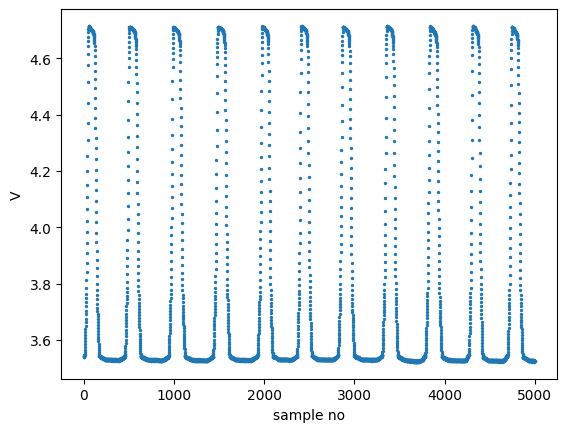

In [15]:
data = []
times = []

'''
nsamples = 10000
sample_time = 5
sample_freq = nsamples/sample_time
''' 
sample_time = 5
sample_freq = 1000
nsamples = sample_freq*sample_time

start = time.time()

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan("Dev3/ai1", terminal_config=TerminalConfiguration.RSE, min_val=-.2, max_val=5)
    task.timing.cfg_samp_clk_timing(sample_freq, sample_mode=AcquisitionType.FINITE, samps_per_chan=nsamples)
    data = task.read(READ_ALL_AVAILABLE)
    
    end = time.time()
    times = np.linspace(0, end-start, len(data))

    print("Acquired data: [" + ", ".join(f"{value:f}" for value in data) + "]")

plt.scatter(np.linspace(0, len(data[1:]), len(data[1:])), data[1:],2)
plt.ylabel('V')
plt.xlabel("sample no")

In [16]:
#save data
file = open("data_lab3_task1.txt", "w+")
for i in range(len(data)):
    file.write(str(data[i]) + "\n")
file.close()

Q1: what does the signal look like?

It's periodic with the shadow making voltage higher.

Q2: what is the optimal voltage range to measure this signal?

For this signal, considering the available settings of the device, the optimal would be to measure between 1 V and 5 V. Though internally it still would do -5 to 5 (as per the TA)

Q3: What are the units on the x- and y-axis on the graph?

I'm plotting volts dependant on sample nr.


Note: I'm sharing the input device. Some code variation may arise!

## Task2



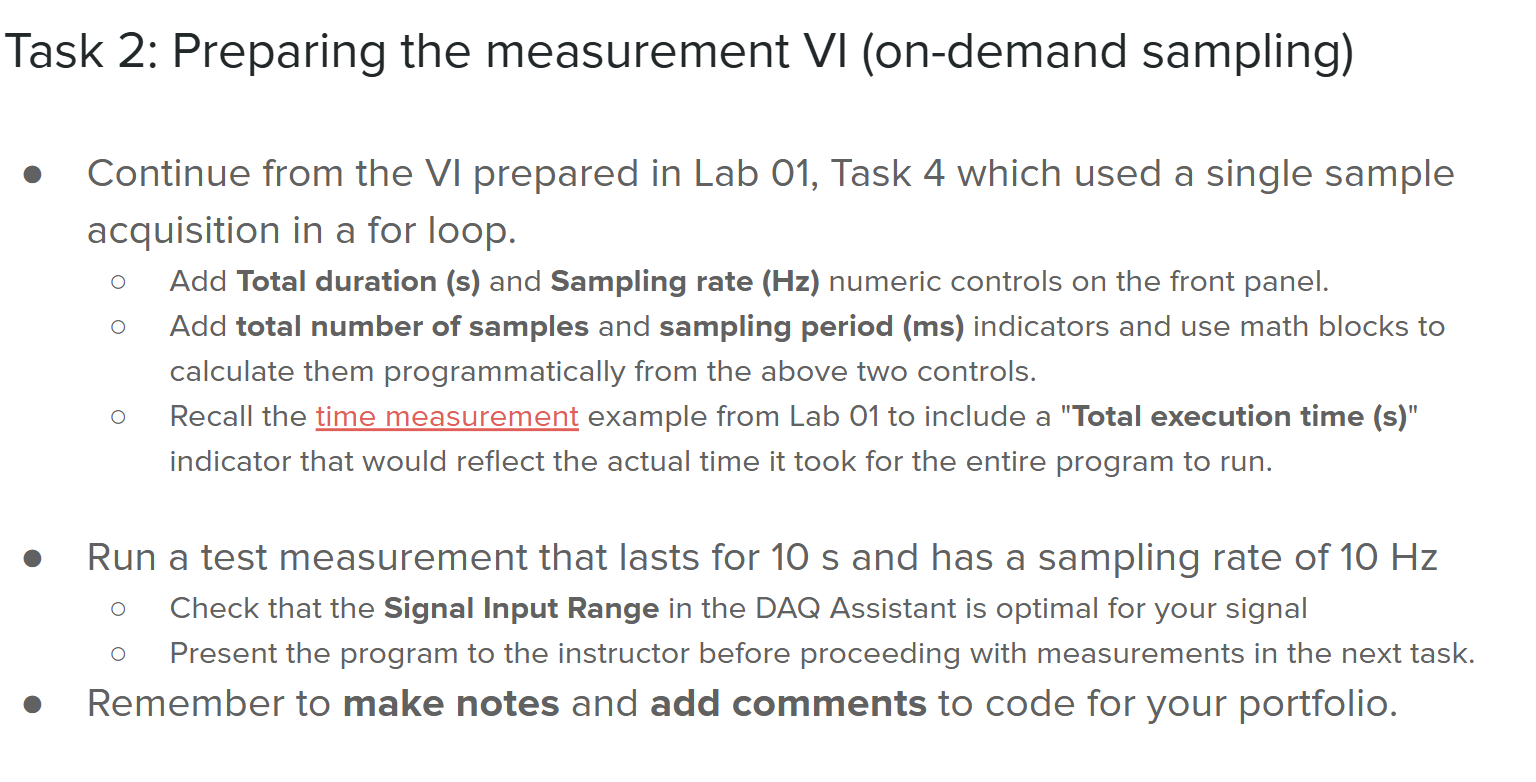

In [23]:
data2 = []
times2 = []

'''
nsamples = 10000
sample_time = 5
sample_freq = nsamples/sample_time
''' 
sample_time = 10
sample_freq = 10
nsamples = sample_freq*sample_time

start = time.time()

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan("Dev3/ai1", terminal_config=TerminalConfiguration.RSE, min_val=1, max_val=5)
    task.timing.cfg_samp_clk_timing(sample_freq, sample_mode=AcquisitionType.FINITE, samps_per_chan=nsamples)
    data2 = task.read(READ_ALL_AVAILABLE)
    
    end = time.time()
    times2 = np.linspace(0, 1e3*(end-start), len(data2)) #sample measurements times in ms

    print("Acquired data: [" + ", ".join(f"{value:f}" for value in data2) + "]")


Acquired data: [4.546802, 3.533845, 3.532694, 3.534832, 4.699759, 3.534667, 3.531542, 3.534338, 4.697950, 3.535819, 3.533023, 3.531378, 4.198622, 3.787288, 3.534009, 3.531871, 3.538779, 4.695318, 3.534338, 3.533516, 3.531049, 4.257995, 3.571343, 3.531378, 3.531707, 4.329703, 3.572166, 3.533187, 3.531049, 3.699792, 4.599926, 3.532200, 3.530885, 3.535819, 4.695647, 3.534503, 3.531871, 3.530062, 3.785973, 4.461607, 3.533516, 3.531049, 3.534174, 4.696305, 3.535654, 3.530227, 3.531214, 4.695483, 3.535654, 3.531378, 3.531542, 4.182669, 3.686141, 3.532200, 3.530556, 3.538779, 4.696634, 3.533845, 3.532036, 3.530227, 4.606834, 3.593875, 3.532365, 3.530062, 3.538121, 4.691700, 3.532858, 3.531214, 3.536641, 4.696798, 3.533187, 3.531871, 3.529240, 3.974452, 4.014582, 3.531378, 3.530885, 3.537134, 4.695812, 3.534009, 3.530227, 3.530885, 4.184807, 3.583349, 3.532858, 3.530556, 4.224115, 3.581211, 3.532858, 3.530227, 3.713772, 4.629530, 3.532529, 3.531871, 3.534996, 4.697292, 3.536148, 3.532529, 3.53

Text(0.5, 0, 'time (ms)')

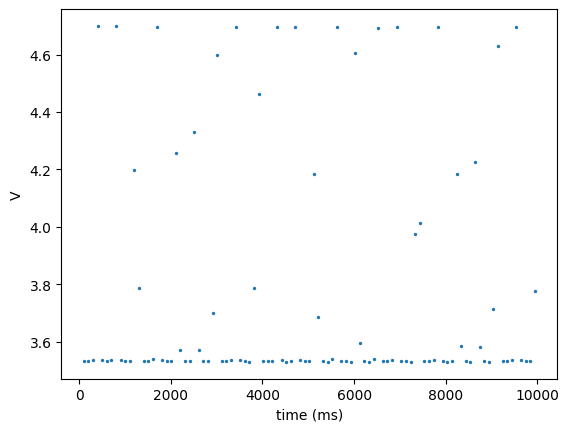

In [ ]:
plt.scatter(times2[1:], data2[1:],2)
plt.ylabel('V')
plt.xlabel("time (ms)")

In [27]:
file = open("data_lab3_task2.txt", "w+")
for i in range(len(data2)):
    file.write(str(data2[i]) + ',' + str(times2[i])+ "\n")
file.close()

## Task 3

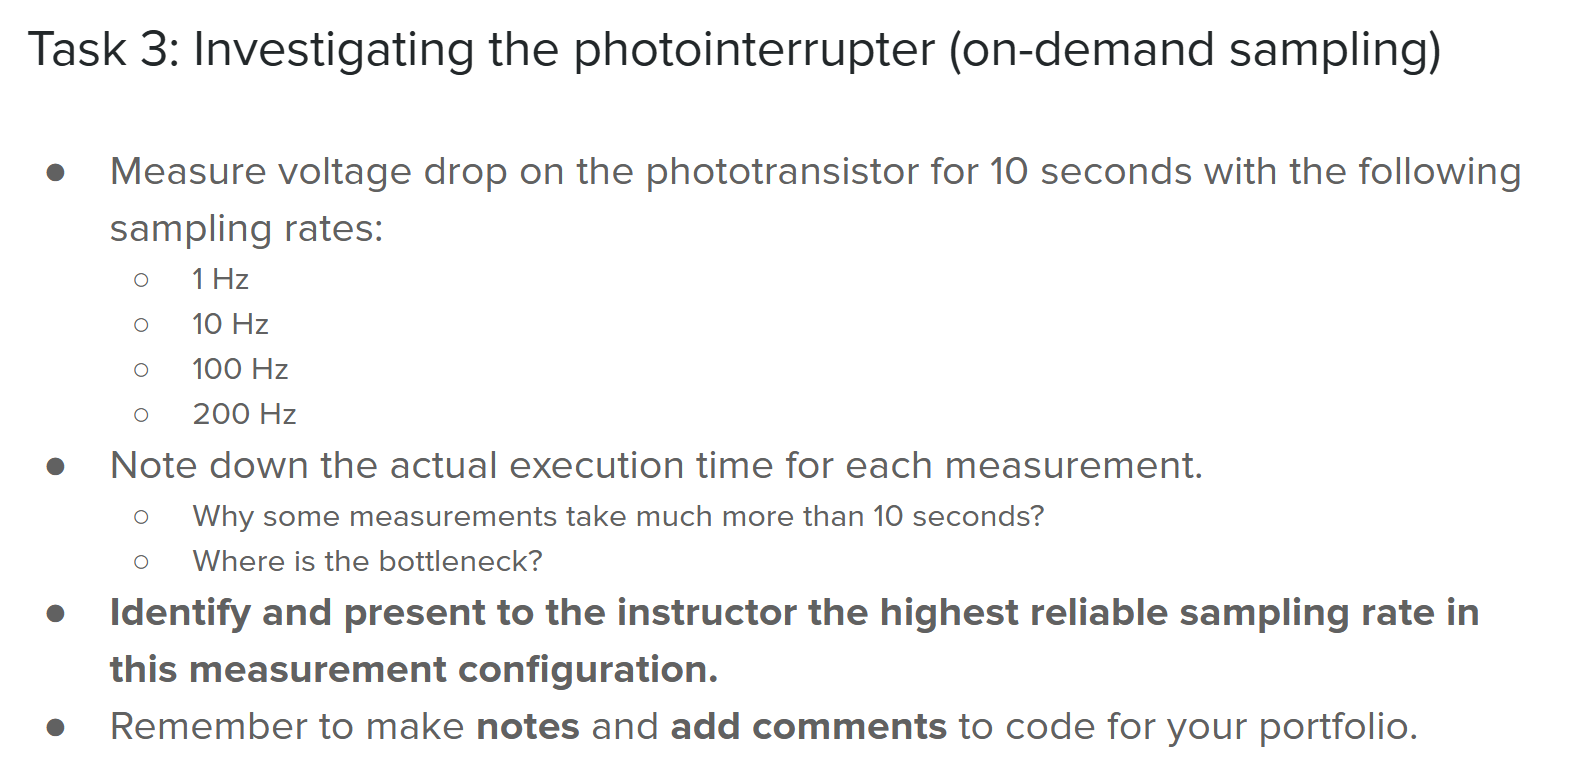

In [65]:
datas3 = []
times3 = []

sample_time = 10
sample_freques = [1, 10, 100, 200, int(1e5)]

for i in range(len(sample_freques)):
    start = time.time()
    with nidaqmx.Task() as task:
        task.ai_channels.add_ai_voltage_chan("Dev3/ai1", terminal_config=TerminalConfiguration.RSE, min_val=1, max_val=5)
        task.timing.cfg_samp_clk_timing(sample_freques[i], sample_mode=AcquisitionType.FINITE, samps_per_chan=sample_freques[i]*sample_time)
        datas3 += [task.read(READ_ALL_AVAILABLE)]
        
        end = time.time()
        times3 += [[np.linspace(0, 1e3*(end-start), len(datas3[i]))]] #sample measurements times in ms


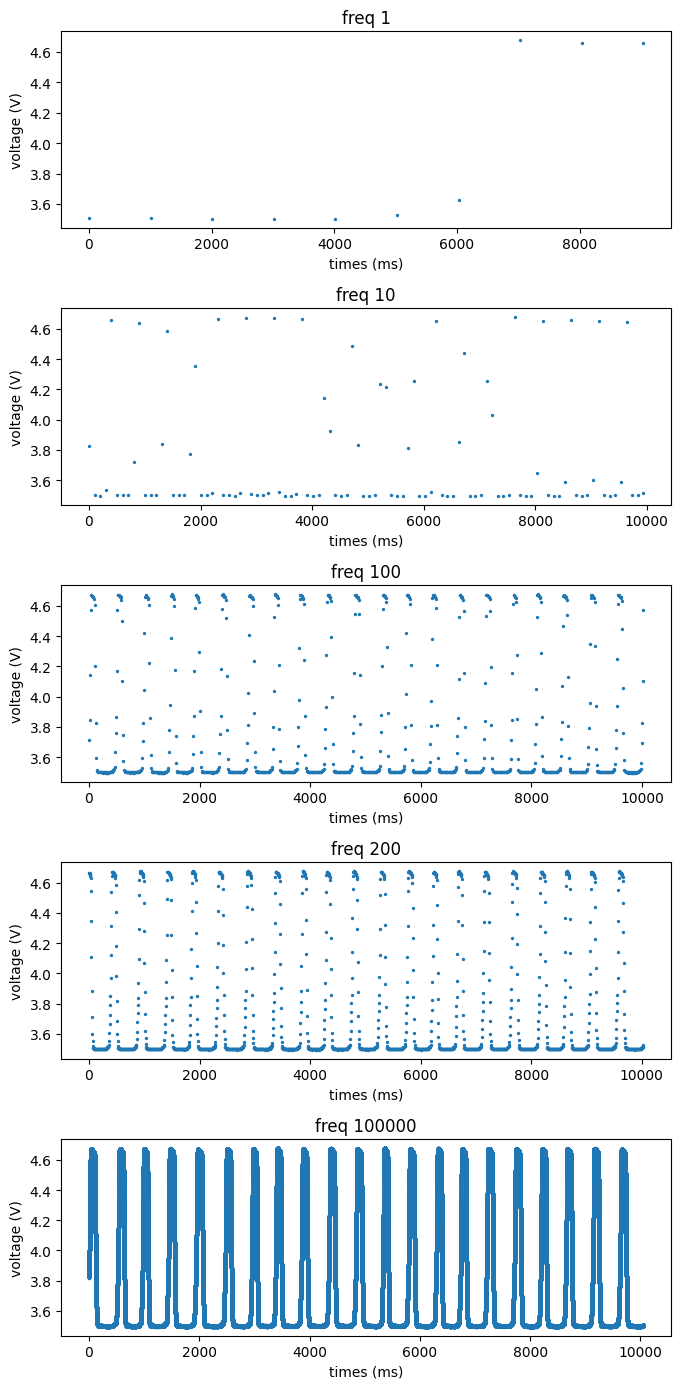

In [67]:
fig, ax = plt.subplots(len(sample_freques), figsize = (7,14))
for i in range(len(sample_freques)):
    ax[i].scatter(times3[i], datas3[i],2)
    ax[i].set_title('freq '+ str(sample_freques[i]))
    ax[i].set_ylabel('voltage (V)')
    ax[i].set_xlabel('times (ms)')

fig.tight_layout()
plt.show()

In [78]:
with open('data_lab3_task345.pkl', 'wb') as f:  # open a text file
    pickle.dump([times3, datas3], f)

Questions:

Why some measurements take much more than 10 seconds?

None take more, 10 Hz takes less, because there are 10 samples, first one at time 0, last at time 9

Where is the bottleneck?

With my implementation there appears to be none. 

## On demand sucks



In [74]:
sample_time = 10
sample_freques = [1, 10, 50, 100, 200]
datas_trash = []
times_on_demand = []

for i in range(len(sample_freques)):
    start = time.time()
    datas_trash += [[]]
    for j in range(sample_freques[i]*sample_time):
        with nidaqmx.Task() as task:
            task.ai_channels.add_ai_voltage_chan("Dev3/ai1", terminal_config=TerminalConfiguration.RSE, min_val=1, max_val=5)
            task.timing.cfg_samp_clk_timing(sample_freques[i], sample_mode=AcquisitionType.FINITE, samps_per_chan=2)
            datas_trash[i] += [task.read(READ_ALL_AVAILABLE)[0]]
        time.sleep(1/sample_freques[i])
    end = time.time()
    times_on_demand += [1e3*(end-start)] #ms

Text(0.5, 0, 'measurement frequency (Hz)')

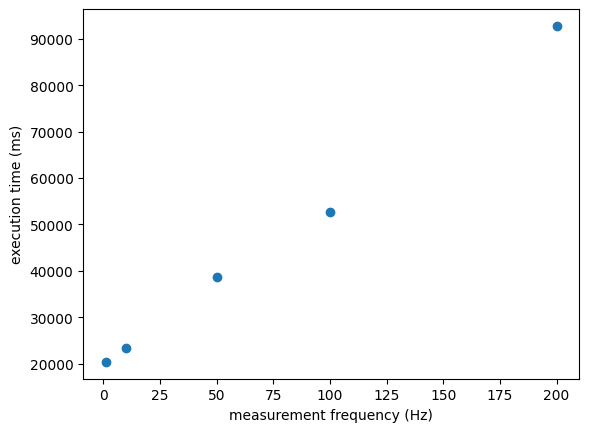

In [76]:
plt.scatter(sample_freques, times_on_demand)
plt.ylabel('execution time (ms)')
plt.xlabel("measurement frequency (Hz)")

In [79]:
with open('data_lab3_onDemand.pkl', 'wb') as f:  # open a text file
    pickle.dump([sample_freques, times_on_demand], f)

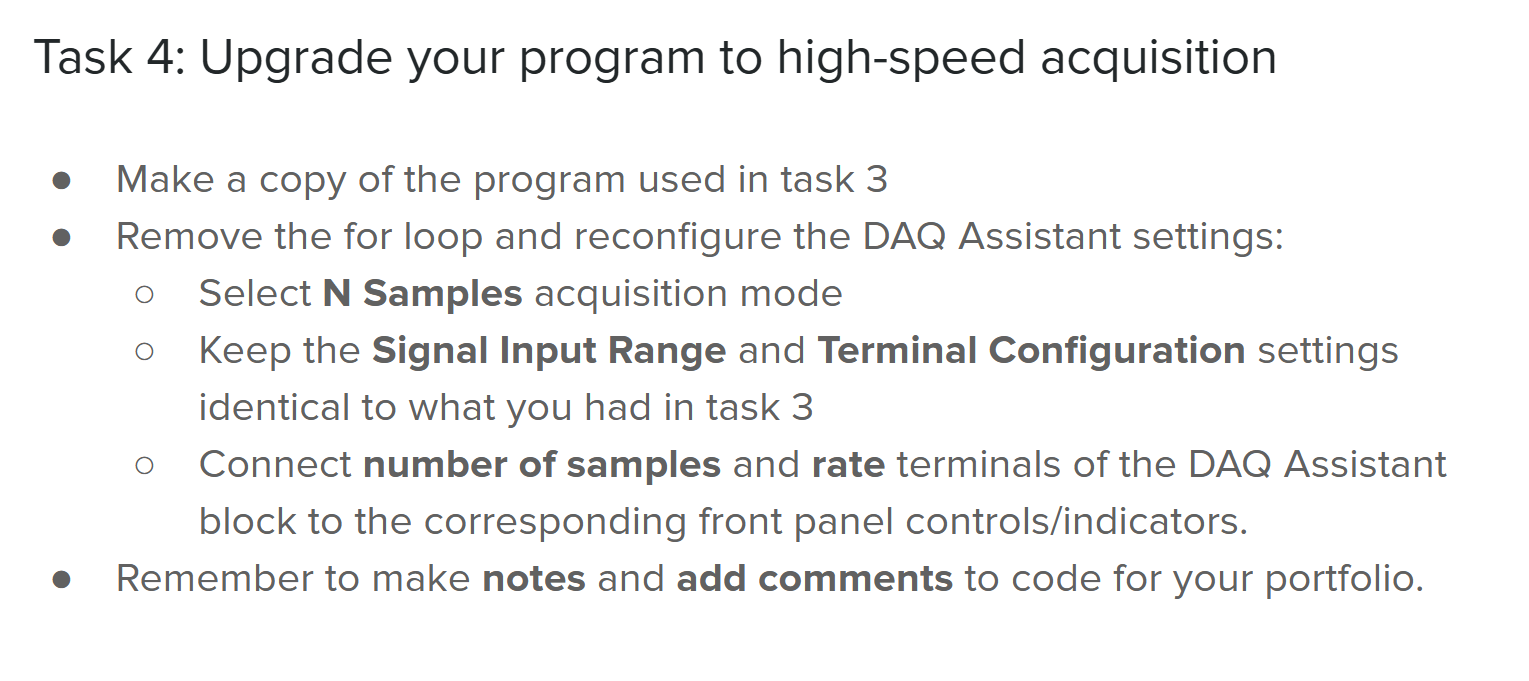
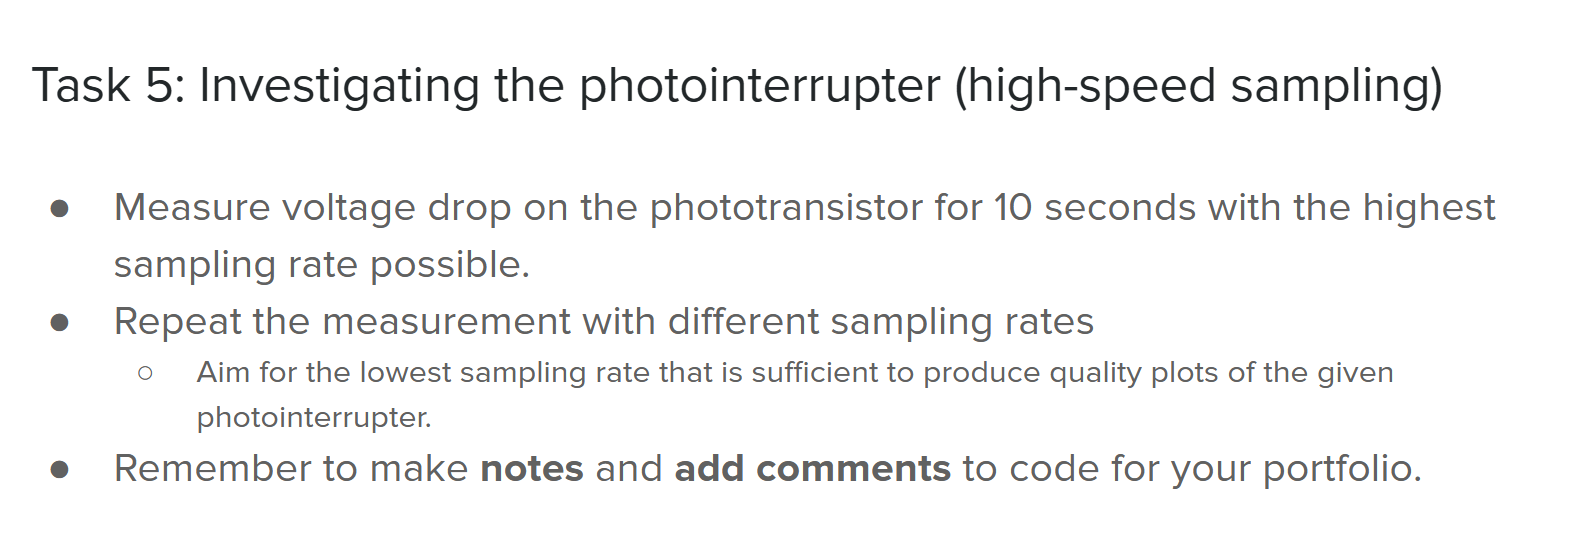